In [1]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns





In [2]:
studentdata=pd.read_csv(r"C:\Users\SAHOO\OneDrive\Desktop\mldataset\student+performance\student\student-mat.csv", sep=';')
studentdata

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [3]:
studentdata.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
studentdata.shape

(395, 33)

In [5]:
studentdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
studentdata.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [7]:
print(studentdata.head())
print(studentdata.info())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (to

In [8]:
studentdata['result'] = studentdata['G3'].apply(lambda x: 1 if x >= 10 else 0)

In [11]:
studentdata = studentdata.drop(['G3'], axis=1, errors='ignore')


In [13]:
studentdata = studentdata[['age','studytime','failures','absences','G1','G2','result']]

In [14]:
studentdata = pd.get_dummies(studentdata, drop_first=True)

In [15]:
input_data = studentdata.drop('result', axis=1)
output = studentdata['result']

In [16]:
#to check unique values
for i in studentdata.columns:
         print(i,':',studentdata[i].unique())

age : [18 17 15 16 19 22 20 21]
studytime : [2 3 1 4]
failures : [0 3 2 1]
absences : [ 6  4 10  2  0 16 14  7  8 25 12 54 18 26 20 56 24 28  5 13 15 22  3 21
  1 75 30 19  9 11 38 40 23 17]
G1 : [ 5  7 15  6 12 16 14 10 13  8 11  9 17 19 18  4  3]
G2 : [ 6  5  8 14 10 15 12 18 16 13  9 11  7 19 17  4  0]
result : [0 1]


In [17]:
print(studentdata['result'].value_counts())

1    265
0    130
Name: result, dtype: int64


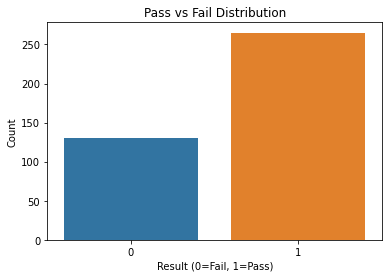

In [18]:
sns.countplot(x='result', data=studentdata)

plt.title("Pass vs Fail Distribution")
plt.xlabel("Result (0=Fail, 1=Pass)")
plt.ylabel("Count")

plt.show()

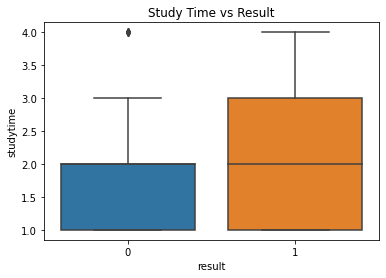

In [19]:
sns.boxplot(x='result', y='studytime', data=studentdata)

plt.title("Study Time vs Result")

plt.show()

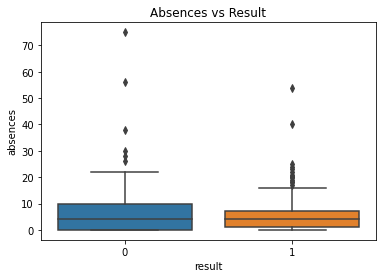

In [20]:
sns.boxplot(x='result', y='absences', data=studentdata)

plt.title("Absences vs Result")

plt.show()

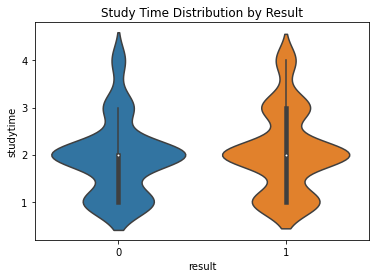

In [21]:
sns.violinplot(x='result', y='studytime', data=studentdata)

plt.title("Study Time Distribution by Result")

plt.show()

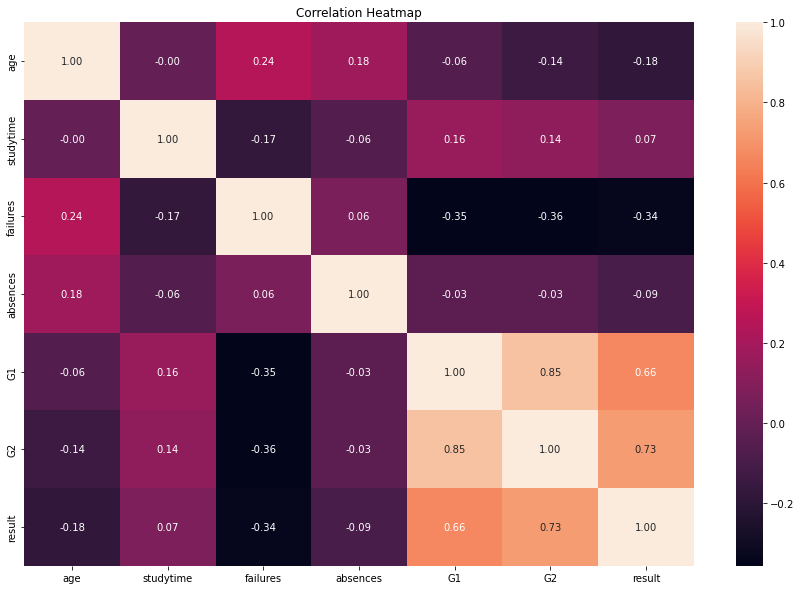

In [22]:
plt.figure(figsize=(15,10))

sns.heatmap(studentdata.corr(), annot=True, fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

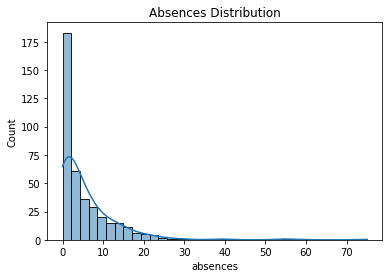

In [23]:
sns.histplot(studentdata['absences'], kde=True)

plt.title("Absences Distribution")

plt.show()

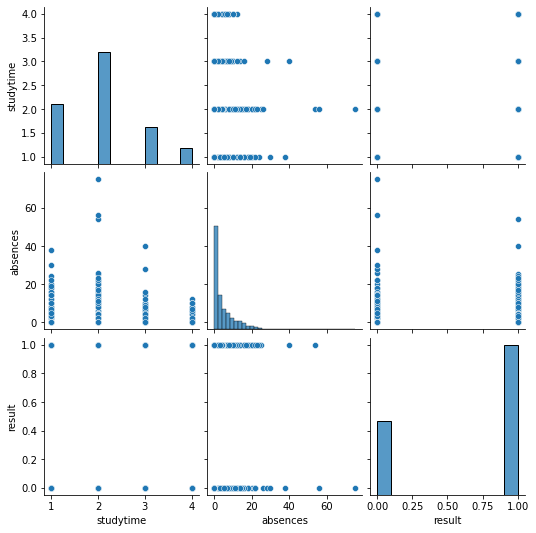

In [24]:
sns.pairplot(studentdata[['studytime','absences','result']])

plt.show()

In [25]:
from sklearn.model_selection import train_test_split

input_train, input_test, output_train, output_test = train_test_split(
    input_data, output, test_size=0.2, random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)
model.fit(input_train, output_train)

RandomForestClassifier(n_estimators=200)

In [27]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

pred = model.predict(input_test)

print("Accuracy ------>", accuracy_score(output_test, pred))
print("Recall -------->", recall_score(output_test, pred))
print("Precision ----->", precision_score(output_test, pred))
print("F1 Score ------>", f1_score(output_test, pred))

Accuracy ------> 0.9113924050632911
Recall --------> 0.9230769230769231
Precision -----> 0.9411764705882353
F1 Score ------> 0.9320388349514563


In [29]:
print("Features used:", model.n_features_in_)

Features used: 6


In [30]:
predicted_output = model.predict(input_test)

In [31]:
import pickle

pickle.dump(model, open(
"C:/Users/SAHOO/OneDrive/Desktop/dJangoml/student_project/predictor/model.pkl",
"wb"
))